In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Correct relative path (tabular_4)
file_path = "./tabular_rex_train.csv"   # 若还没切分，可用 "./tabular4.csv"
label_col = "label"

# Load dataset
df_train = pd.read_csv(file_path)

# 兼容：如果还是原始列名，就顺手改成 label
if "Diabetes_012" in df_train.columns and "label" not in df_train.columns:
    df_train = df_train.rename(columns={"Diabetes_012": "label"})

print("Data shape:", df_train.shape)
print("Columns:", list(df_train.columns))





Data shape: (152207, 18)
Columns: ['label', 'Age', 'Sex', 'BMI', 'GenHlth', 'HighBP', 'DiffWalk', 'HighChol', 'HeartDiseaseorAttack', 'site_id', 'Age_mask', 'Sex_mask', 'BMI_mask', 'GenHlth_mask', 'HighBP_mask', 'DiffWalk_mask', 'HighChol_mask', 'HeartDiseaseorAttack_mask']


In [3]:
%pip install -U pip
%pip install pandas numpy matplotlib seaborn scikit-learn


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:

corr = df_train.corr(numeric_only=True)


corr_series = corr[label_col].drop(labels=[label_col], errors='ignore')
corr_abs_sorted = corr_series.abs().sort_values(ascending=False)

print("\nTop 15 correlated features with label:")
print(corr_series.reindex(corr_abs_sorted.index[:15]))



Top 15 correlated features with label:
GenHlth                      0.298645
HighBP                       0.270010
DiffWalk                     0.224096
BMI                          0.221542
HighChol                     0.204832
Age                          0.183880
HeartDiseaseorAttack         0.180860
Sex                          0.033243
BMI_mask                    -0.002835
HeartDiseaseorAttack_mask    0.002327
Sex_mask                     0.002308
HighBP_mask                 -0.002102
DiffWalk_mask               -0.001086
Age_mask                    -0.001005
GenHlth_mask                -0.000943
Name: label, dtype: float64


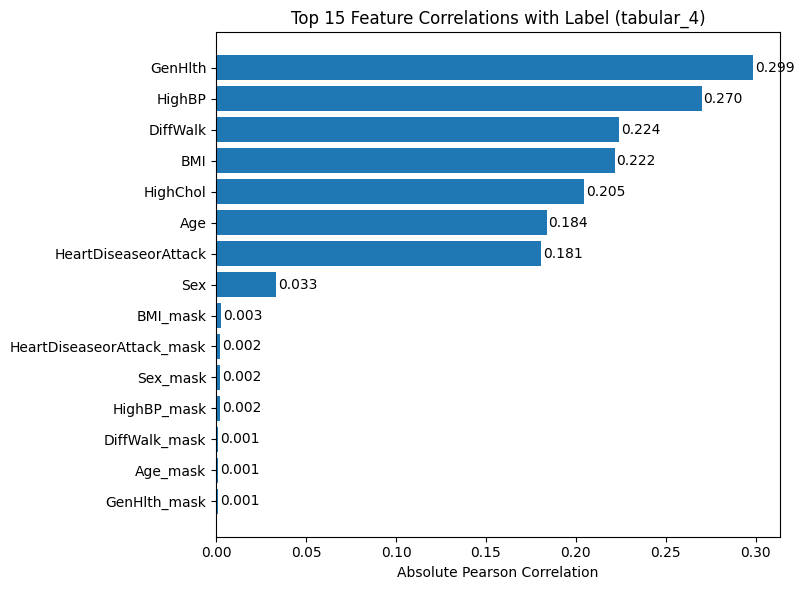

In [ ]:
# Visualize top 15 absolute correlations (matplotlib only)
vals = corr_abs_sorted.values[:15]
names = corr_abs_sorted.index[:15]

plt.figure(figsize=(8,6))
ypos = np.arange(len(names))
plt.barh(ypos, vals)
plt.yticks(ypos, names)
plt.gca().invert_yaxis() 
plt.title("Top 15 Feature Correlations with Label (tabular_4)")
plt.xlabel("Absolute Pearson Correlation")
plt.tight_layout()


for i, v in enumerate(vals):
    plt.text(v + 0.001, i, f"{v:.3f}", va="center")

plt.show()


In [ ]:
# Select the final 8 template features and save  (tabular_4)
# Prerequisite: corr_abs_sorted and df_train, label_col are already defined

from collections import OrderedDict
import json
import pandas as pd
from pathlib import Path


core_features = ["Age", "Sex", "BMI"]


candidates = [c for c in corr_abs_sorted.index if c != label_col]

merged = list(OrderedDict.fromkeys(core_features + candidates))
merged = [c for c in merged if c in df_train.columns and c != label_col]


mask_features = merged[:8]
if len(mask_features) < 8:
    others = [c for c in df_train.columns if c not in mask_features + [label_col]]
    mask_features = (mask_features + others)[:8]

print("Final 8 template features:", mask_features)


out_dir = Path("feature_templates")
out_dir.mkdir(exist_ok=True)

# CSV（
pd.Series(mask_features, name="feature").to_csv(out_dir / "feature_template_v1.csv", index=False)

# JSON
template_meta = {
    "version": "v1",
    "label": "label",          
    "features": mask_features
}
(out_dir / "feature_template_v1.json").write_text(json.dumps(template_meta, indent=2), encoding="utf-8")

print("Saved:", out_dir / "feature_template_v1.csv")
print("Saved:", out_dir / "feature_template_v1.json")


Final 8 template features: ['Age', 'Sex', 'BMI', 'GenHlth', 'HighBP', 'DiffWalk', 'HighChol', 'HeartDiseaseorAttack']
Saved: feature_templates/feature_template_v1.csv
Saved: feature_templates/feature_template_v1.json
